In [1]:
! pip list

Package                   Version
------------------------- ------------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
brotlicffi                1.2.0.0
certifi                   2026.7.22
cffi                      2.1.0
charset-normalizer        3.4.7
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
dnspython                 2.8.0
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.63.0
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.18
ipykernel     

In [6]:
from pymongo import MongoClient

In [4]:
# MongoDB 로컬 서버 연결
client = MongoClient("mongodb://localhost:27017/") # mongodb 접속 포트 : 27017

# MongoDB 데이터 베이스 생성
db = client["advanced_ai"]

# 컬렉션 생성 (RDBSM의 테이블과 같음)
collection = db["students"]

# 데이터 삽입
collection.insert_one({"name": "홍길동", "age": 23, "major" : "컴퓨터공학"})

InsertOneResult(ObjectId('6a7bbd3ff3620a8923090e3c'), acknowledged=True)

In [6]:
collection.insert_one({
    "id" : 10,
    "name" : "홍길동2",
    "age" : 30,
    "major" : "컴퓨터공학"
})

InsertOneResult(ObjectId('6a7bbde7f3620a8923090e3d'), acknowledged=True)

In [7]:
collection.insert_one({
    "_id" : 11,
    "name" : "홍길동2",
    "age" : 30,
    "major" : "컴퓨터공학"
})

InsertOneResult(11, acknowledged=True)

# 기본 CRUD 실습
 : CRUD는 Create, Read, Update, Delete의 약자

In [10]:
# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")

db = client["advanced_ai"]

collection = db["students"]

# Create
collection.insert_many([
    {
        "name" : "홍길동3",
        "age" : 21,
        "major" : "물리학"
    },
    {
        "name" : "홍길동4",
        "age" : 22,
        "major" : "영문학"
    },
    {
        "name" : "홍길동5",
        "age" : 23,
        "major" : "수리학"
    },
    {
        "name" : "홍길동6",
        "age" : 23,
        "major" : "전자공학"
    },
    {
        "name" : "홍길동7",
        "age" : 24,
        "major" : "경제학"
    },
    {
        "name" : "홍길동8",
        "age" : 22,
        "major" : "경영학"
    },    
    {
        "name" : "홍길동9",
        "age" : 25,
        "major" : "법학"
    }
])


InsertManyResult([ObjectId('6a7bbfd5f3620a8923090e41'), ObjectId('6a7bbfd5f3620a8923090e42'), ObjectId('6a7bbfd5f3620a8923090e43'), ObjectId('6a7bbfd5f3620a8923090e44'), ObjectId('6a7bbfd5f3620a8923090e45'), ObjectId('6a7bbfd5f3620a8923090e46'), ObjectId('6a7bbfd5f3620a8923090e47')], acknowledged=True)

In [12]:
# Update
collection.update_one({"name" : "홍길동5"}, {"$set" : {"age" : 45}})

UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [13]:
# Delete

collection.delete_one({"name" : "홍길동5"})

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [15]:
# Read
for student in collection.find():
    print(student)

client.close()

{'_id': ObjectId('6a7bbd3ff3620a8923090e3c'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a7bbde7f3620a8923090e3d'), 'id': 10, 'name': '홍길동2', 'age': 30, 'major': '컴퓨터공학'}
{'_id': 11, 'name': '홍길동2', 'age': 30, 'major': '컴퓨터공학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e41'), 'name': '홍길동3', 'age': 21, 'major': '물리학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e42'), 'name': '홍길동4', 'age': 22, 'major': '영문학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e44'), 'name': '홍길동6', 'age': 23, 'major': '전자공학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e45'), 'name': '홍길동7', 'age': 24, 'major': '경제학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e46'), 'name': '홍길동8', 'age': 22, 'major': '경영학'}
{'_id': ObjectId('6a7bbfd5f3620a8923090e47'), 'name': '홍길동9', 'age': 25, 'major': '법학'}


# CSV 파일 >> MongoDB 저장

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('Subjects.csv')
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


In [ ]:
# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students_csv"]

collection.insert_many(df.to_dict("records")) # df라는 dataframe을 [{},{},[}...] 형태의 리스트로 변환
print("csv 데이터가 mongodb에 저장되었습니다.")

InsertManyResult([ObjectId('6a7bc9e13bd36da9bcb14a6d'), ObjectId('6a7bc9e13bd36da9bcb14a6e'), ObjectId('6a7bc9e13bd36da9bcb14a6f'), ObjectId('6a7bc9e13bd36da9bcb14a70'), ObjectId('6a7bc9e13bd36da9bcb14a71'), ObjectId('6a7bc9e13bd36da9bcb14a72'), ObjectId('6a7bc9e13bd36da9bcb14a73'), ObjectId('6a7bc9e13bd36da9bcb14a74'), ObjectId('6a7bc9e13bd36da9bcb14a75'), ObjectId('6a7bc9e13bd36da9bcb14a76'), ObjectId('6a7bc9e13bd36da9bcb14a77'), ObjectId('6a7bc9e13bd36da9bcb14a78')], acknowledged=True)

In [8]:
# read
for student_csv in collection.find():
  print(student_csv)

client.close()

{'_id': ObjectId('6a7bc9e13bd36da9bcb14a6d'), 'class': 1, 'name': 'aaa', 'kor': 67, 'eng': 87, 'math': 90, 'science': 98}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a6e'), 'class': 1, 'name': 'bbb', 'kor': 45, 'eng': 45, 'math': 56, 'science': 98}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a6f'), 'class': 1, 'name': 'ccc', 'kor': 95, 'eng': 59, 'math': 96, 'science': 88}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a70'), 'class': 1, 'name': 'ddd', 'kor': 65, 'eng': 94, 'math': 89, 'science': 98}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a71'), 'class': 1, 'name': 'eee', 'kor': 45, 'eng': 65, 'math': 78, 'science': 98}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a72'), 'class': 1, 'name': 'fff', 'kor': 78, 'eng': 76, 'math': 98, 'science': 89}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a73'), 'class': 2, 'name': 'ggg', 'kor': 87, 'eng': 67, 'math': 65, 'science': 56}
{'_id': ObjectId('6a7bc9e13bd36da9bcb14a74'), 'class': 2, 'name': 'hhh', 'kor': 89, 'eng': 98, 'math': 78, 'science': 78}
{'_id': ObjectId('6a7bc9

# 1) 이미지 >> MongoDB에 저장

* 이미지 저장 : 이미지 --> base64 --> 바이너리로 변환(encoding) --> 저장
* 이미지 불러오기 : base64 --> 바이너리 --> 이미지 객체로 변환(decoding)하여 출력

In [9]:
import base64
from io import BytesIO

In [10]:
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["images"]

In [13]:
# 이미지 읽어오기
with open("images.jpg", "rb") as img_file:
  encoded = base64.b64encode(img_file.read()).decode("utf-8")

# MongoDB에 저장
collection.insert_one({"filename" : "cat.jpg", "data" : encoded})


InsertOneResult(ObjectId('6a7bce0e3bd36da9bcb14a7a'), acknowledged=True)

# 2) MongoDB image --> python 출력

In [14]:
from PIL import Image

MongoDB에서 이미지를 읽어왔습니다.


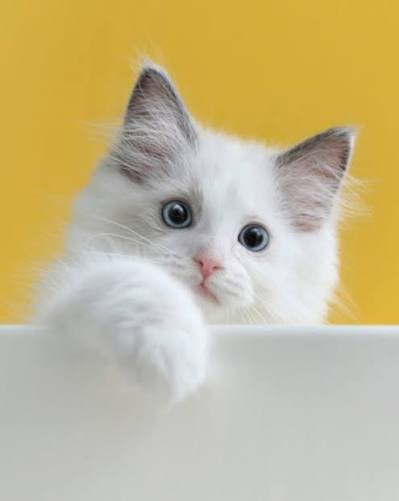

In [16]:
#mongodb에서 이미지 데이터 가져오기
document = collection.find_one({"filename" : "cat.jpg"})
if document:
  img_data = document["data"]
  img_binary = base64.b64decode(img_data)
  img = Image.open(BytesIO(img_binary))
  print("MongoDB에서 이미지를 읽어왔습니다.")
  display(img)
else:
  print("cat.jpg 이미지를 찾을 수 없습니다.")

# 3) MongoDB student_csv 컬렉션에 있는 데이터를 읽어와 영어점수 막대 그래프를 출력하기

In [17]:
import pandas as pd                             # 데이터 시각화 처리
import seaborn as sns                           # 시각화 라이브러리
import matplotlib.pyplot as plt                 # 시각화 라이브러리
from matplotlib import font_manager, rc         # 한글처리 매니저
from pymongo import MongoClient                 # 몽고db 라이브러리

    class name  kor  eng  math  science
0       1  aaa   67   87    90       98
1       1  bbb   45   45    56       98
2       1  ccc   95   59    96       88
3       1  ddd   65   94    89       98
4       1  eee   45   65    78       98
5       1  fff   78   76    98       89
6       2  ggg   87   67    65       56
7       2  hhh   89   98    78       78
8       2  iii  100   78    56       65
9       2  jjj   99   89    87       87
10      2  kkk   98   45    56       54
11      2  lll   65   89    87       78


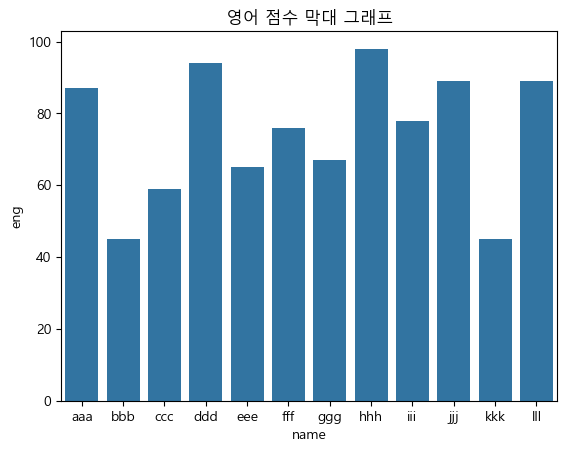

In [23]:
# 한글 폰트 설정
font_path = "/mnt/c/Windows/Fonts/malgun.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)
plt.rcParams["font.family"] = font_name

# 음수 값 표시 방지
plt.rcParams["axes.unicode_minus"] = False

# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students_csv"]

# MongoDB --> 파이썬 (DataFrame 으로 변환)
data = pd.DataFrame(list(collection.find({}, {"_id" : 0})))
print(data)

# 시각화
sns.barplot(data = data, x = "name", y = "eng")
plt.title("영어 점수 막대 그래프")
plt.show()

#db 종료
client.close()

# 1) 몽고 DB 연결 -> students 컬렉션 데이터를 읽어오기

# 2) 파이썬으로 그래프 출력하기
- 학생별 나이 분포
- 전공 별 학생 수
- 전공 별 나이 분포

/tmp/ipykernel_27898/41187920.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="major", data=df, palette="pastel")
/tmp/ipykernel_27898/41187920.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="age", data=df,  palette="Set2")


<function matplotlib.pyplot.show(close=None, block=None)>

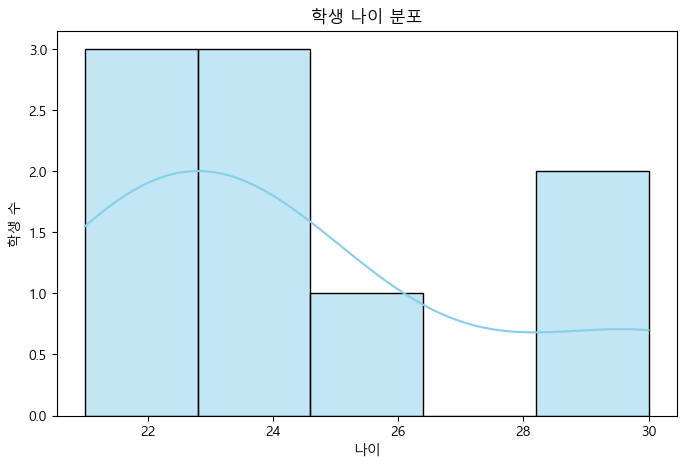

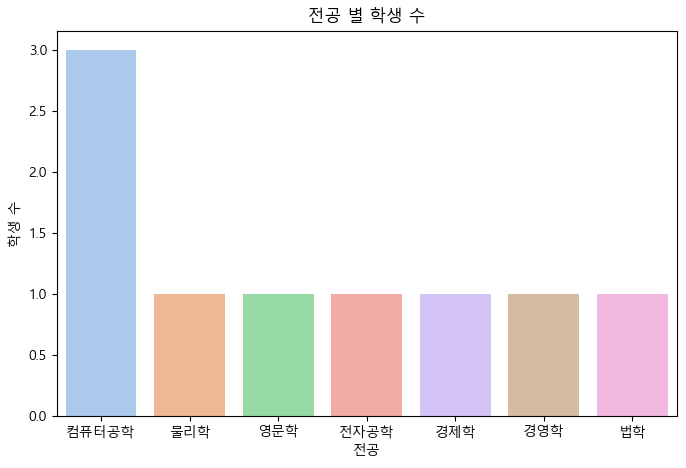

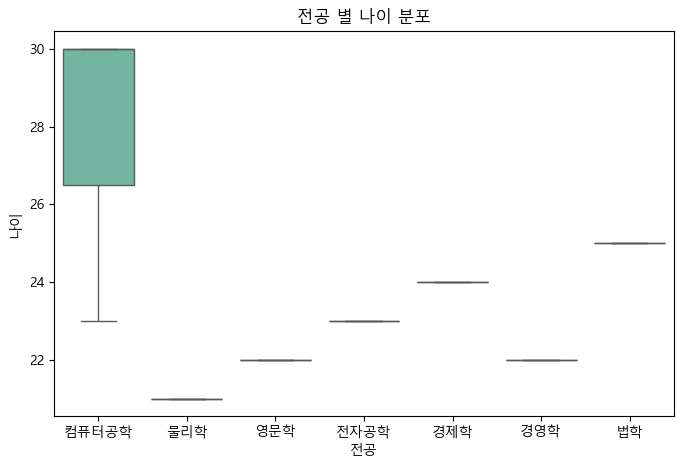

In [29]:
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

## 한글 폰트 설정 (Windows)

# Windows 기본 폰트: Malgun Gothic
font_path = "/mnt/c/Windows/Fonts/malgun.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)
plt.rcParams["font.family"] = font_name

# 음수 값 표시 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# MongoDB 연결 및 데이터 불러오기  (students 컬렉션)
# -----------------------------
client = MongoClient("mongodb://localhost:27017/")
db = client["advanced_ai"]
collection = db["students"]

df = pd.DataFrame(list(collection.find({}, {"_id" : 0})))
# -----------------------------
#  나이 분포 히스토그램
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=5, kde=True, color="skyblue")
plt.title("학생 나이 분포")
plt.xlabel("나이")
plt.ylabel("학생 수")
plt.show

# -----------------------------
#  전공별 학생 수 막대그래프
# -----------------------------
plt.figure(figsize=(8,5))
sns.countplot(x="major", data=df, palette="pastel")
plt.title("전공 별 학생 수")
plt.xlabel("전공")
plt.ylabel("학생 수")
plt.show


# -----------------------------
#  전공별 나이 분포 박스플롯
# -----------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x="major", y="age", data=df,  palette="Set2")
plt.title("전공 별 나이 분포")
plt.xlabel("전공")
plt.ylabel("나이")
plt.show